In [5]:
from pathlib import Path
import sys
import h5py
import numpy as np
import os
sys.path.append(str(Path(os.getcwd()).parent))
from admm_colin.admmcolinviz import ADMMColin

In [20]:
admmoc = ADMMColin(alpha=0.015, dim=128, base_dir="../admm_colin/run_data_admm_osqp")
from pathlib import Path
r_value = 3.79
mesh_dim = 128
results_root=Path("OC_results_new")
folder = results_root / f"{r_value:.2f}"
file_path = folder / f"{mesh_dim}.h5"

if not file_path.exists():
    print(f"Run file not found: {file_path}")

with h5py.File(file_path, "r") as h5f:
    oc_control = h5f["control_cont"][()]
    oc_control_disc = h5f["control_disc"][()]
    #oc_control_disc_T = _transpose_control_triangles(oc_control_disc, 64)
    oc_r_attr = float(h5f.attrs.get("r", r_value))
    oc_tv_disc = float(h5f["tv_disc"][()])
    oc_compliance_disc = float(h5f["compliance_disc"][()])

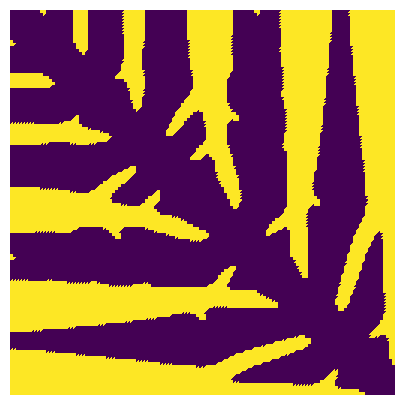

In [21]:
admmoc.plot_control(oc_control_disc)

In [22]:
oc_compliance_disc

0.9628171482253337

In [28]:
import networkx as nx
from pyvis.network import Network

def build_graph(n_x, n_y):
    N = n_x * n_y
    graph = nx.Graph()
    graph.add_nodes_from(range(N))

    for k in range(0, N, 2):
        if k + 1 < N:
            graph.add_edge(k, k + 1)

        if (k + 2) % n_y != 0 and k + 3 < N:
            graph.add_edge(k, k + 3)

        if (k // n_y) != 0:
            nb = k - (n_y - 1)
            if nb >= 0:
                graph.add_edge(k, nb)

    return graph


graph = build_graph(2, 4)

net = Network(
    height="800px",
    width="100%",
    notebook=True,
    cdn_resources="in_line",
)

net.from_nx(graph)

# Label each node by its number
for node in net.nodes:
    node["label"] = str(node["id"])
    #node["physics"] = False
    node["font"] = {"size": 24}

net.toggle_physics(True)
# net.set_options("""
# var options = {
#   "physics": {
#     "enabled": false
#   },
#   "interaction": {
#     "dragNodes": true,
#     "dragView": true,
#     "zoomView": true
#   }
# }
# """)

net.write_html("graph.html")

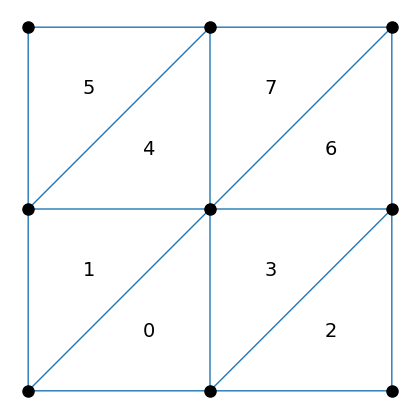

In [26]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np


def plot_unit_square_mesh(n):
    x = np.linspace(0, 1, n + 1)
    y = np.linspace(0, 1, n + 1)
    X, Y = np.meshgrid(x, y)

    points = np.column_stack([X.ravel(), Y.ravel()])
    triangles = []

    for j in range(n):
        for i in range(n):
            bl = j * (n + 1) + i
            br = bl + 1
            tl = bl + (n + 1)
            tr = tl + 1

            triangles.append([bl, br, tr])
            triangles.append([bl, tr, tl])

    triangles = np.array(triangles)

    fig, ax = plt.subplots(figsize=(4, 4))

    triang = mtri.Triangulation(
        points[:, 0],
        points[:, 1],
        triangles
    )

    ax.triplot(triang, linewidth=1)

    #Node labels
    for node, (px, py) in enumerate(points):
        ax.plot(px, py, "ko", markersize=8)
        # ax.text(px, py, str(node), fontsize=7,
        #         ha="center", va="center")

    # Element labels
    for k, tri in enumerate(triangles):
        coords = points[tri]
        cx, cy = coords.mean(axis=0)

        ax.text(cx, cy, str(k),
                fontsize=14,
                ha="center", va="center")

    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout(pad=0)
    plt.show()


plot_unit_square_mesh(2)